## Actividad 1 — Implementación manual de KNN con Iris

El objetivo de esta primera actividad es implementar el procedimiento de KNN sin utilizar `KNeighborsClassifier` de scikit learn

##### Dataset Iris
El dataset Iris es uno de los conjuntos de datos clásicos utilizados para introducir problemas de clasificación. Contiene 150 observaciones de flores, pertenecientes a tres especies:

- Iris setosa
- Iris versicolor
- Iris virginica

Para cada flor se registran cuatro atributos morfológicos, medidos en centímetros: longitud y ancho del sépalo, y longitud y ancho del pétalo. Cada especie contiene 50 observaciones, por lo que las clases están equilibradas.

En esta práctica se utilizarán únicamente la longitud y el ancho del pétalo como atributos de entrada. Esto permite trabajar con una representación sencilla del problema mientras se implementa manualmente el algoritmo KNN.

El objetivo es predecir la especie de una flor a partir de sus características.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import load_iris, load_digits, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
# Cargamos Iris como DataFrame (as_frame=True agrega los nombres de columnas y el target)
iris_df = load_iris(as_frame=True).frame
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
#nos quedamos con las columnas de petal length y petal width
datos = iris_df[['petal length (cm)', 'petal width (cm)']]
datos


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2
...,...,...
145,5.2,2.3
146,5.0,1.9
147,5.2,2.0
148,5.4,2.3


In [4]:
#Variable objetivo: especie de Iris (codificada como 0, 1 o 2)
target = iris_df[['target']]
target

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [5]:
# Dividimos en entrenamiento (70%) y prueba (30%).
set_train, set_test = train_test_split(iris_df, test_size = 0.3, random_state = 1, stratify = iris_df['target'])

In [6]:
class KNN:
    """Clasificador KNN.

    Parámetros
    ------------
    k : int
        número de vecinos cercanos
    p : int
        valor para selección de métrica (1: Manhattan, 2: Euclídea)
    """

    def __init__(self, k=3, p=2):
        self.k = k
        self.p = p

    def distancia(self, vec_1, vec_2, p=2):
        """Función que calcula la distancia entre dos vectores."""
        dim = len(vec_1)
        distance=0

        for d in range(dim):
            distance += (abs(vec_1[d]-vec_2[d]))**p

        distance = (distance)**(1/p)
        return distance

    def fit(self, X, y):
        """Entrenamiento del clasificador kNN, es un algoritmo 'perezoso'
        sólo almacena los datos y sus etiquetas
        Parameters
        ----------
        X : array
            vector de características.
        y : array
            clases asociadas a los datos.
        """
        self.X = np.asarray(X)
        self.y = np.asarray(y)
        self.n_datos = X.shape[0]

    def predict(self, x):
        """Función que realiza la predicción.
        Parameters
        ----------
        x : array
            vector de patrones de entrada.

        Returns
        -------
        vector de predicciones.
        """
        y_pred = []

        for punto_prueba in np.asarray(x):
            #1. distancia del punto de prueba a cada punto de entrenamiento
            distancias = np.array([ self.distancia(punto_prueba, x_train, self.p) for x_train in self.X]) 
            #2 y 3. ordenamos las distancias y nos quedamos con los k índices más cercanos
            indices_vecinos = np.argsort(distancias)[:self.k]
            #4. obtenemos las etiquetas de los vecinos más cercanos
            etiquetas_vecinos = self.y[indices_vecinos]

            #5. votacion --> la clase que más se repite entre los vecinos gana (en caso de empate, 
            #np.unique devuelve las clases ordenadas y argmax se queda con la primera, es decir la de menor valor numérico)
            valores, conteos = np.unique(etiquetas_vecinos, return_counts=True)
            y_pred.append(valores[np.argmax(conteos)])

        return np.asarray(y_pred)

Utilizamos:

- $K=3$
- distancia Euclídea, es decir $p=2$

Calculamos las predicciones sobre el conjunto de prueba y estimamos la tasa de aciertos.

In [7]:
clasificador = KNN(k = 3, p = 2)

#emtrenamos con el conjunto de entrenamiento
clasificador.fit(set_train[['petal length (cm)', 'petal width (cm)']], set_train['target'])

#predecimos sobre el conjunto de prueba
prediccion = clasificador.predict(set_test[['petal length (cm)', 'petal width (cm)']])

print(prediccion)

[2 0 0 1 1 1 2 1 2 0 0 2 0 1 0 1 2 1 1 2 2 0 1 2 1 1 1 2 0 2 0 0 1 1 2 2 0
 0 0 1 2 2 1 0 0]


In [8]:
#comparamos la prediccion con las etiquetas reales del conjunto de prueba
accuracy = accuracy_score(set_test['target'], prediccion)
accuracy

0.9777777777777777

## Actividad 2 — KNN con `scikit-learn`: reconocimiento de dígitos

##### Dataset Digits

El dataset Digits contiene imágenes de dígitos manuscritos correspondientes a las clases del 0 al 9.

El conjunto posee 1797 imágenes. Cada imagen tiene una resolución de $8 \times 8$ píxeles, por lo que cada instancia puede representarse mediante un vector de $8 \times 8 = 64$ atributos.

Cada atributo representa la intensidad de un píxel, con valores comprendidos entre 0 y 16. De esta manera, una imagen puede representarse tanto como una matriz de $8\times8$ píxeles como mediante un vector de 64 características utilizado por el clasificador.

El problema consiste en utilizar la información de esos píxeles para determinar qué dígito representa cada imagen.

Ahora se utilizará `KNeighborsClassifier` de scikit learn.


In [9]:
digits = load_digits()

X_digits = digits.data
y_digits = digits.target

print("X shape:", X_digits.shape)
print("Classes:", np.unique(y_digits))
print("Pixel value range:", (X_digits.min(), X_digits.max()))

X shape: (1797, 64)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel value range: (np.float64(0.0), np.float64(16.0))


(8, 8)


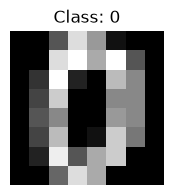

In [10]:
# Visualización de una observación
sample_index = 0

print(digits.images[sample_index].shape)

plt.figure(figsize=(2, 2))
plt.imshow(digits.images[sample_index], cmap="gray")
plt.title(f"Class: {y_digits[sample_index]}")
plt.axis("off")
plt.show()

#### División de entrenamiento, validación y prueba

Utilizar:

- 70 % para **entrenamiento**
- 15 % para **validación**
- 15 % para **prueba**
- `random_state=42`
- muestreo estratificado.

puede hacerse en dos llamadas a `train_test_split`.

In [11]:
#primer split: 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size = 0.3, random_state = 42, stratify = y_digits)

#segundo split: dividimos el 30% de prueba anterior en 50% prueba, 50% validación --> obtenemos 70% entrenamiento, 15% prueba y 15% validación
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42, stratify = y_test)

#### Experimento: métrica de distancia y valor de $K$

Comparar:

- `metric="manhattan"`
- `metric="euclidean"`

para:

$$
K \in \{1,3,5,7,9,11,13,15\}
$$

Para cada combinación:

1. crear un `KNeighborsClassifier`;
2. ajustarlo con entrenamiento;
3. calcular métrica de validación `accuracy_score`;
4. almacenar el resultado.

In [12]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
distance_metrics = ["manhattan", "euclidean"]

resultados = []
for k in k_values:
    for metric in distance_metrics:
        #pipeline: primero estandarizamos los datos y luego aplicamos el clasificador KNN
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, metric=metric))
        ])
        pipeline.fit(X_train, y_train) #entrenamos solo con train
        y_pred = pipeline.predict(X_val) #evaluamos con validacion 

        accuracy = accuracy_score(y_val, y_pred)
        resultados.append((k, metric, accuracy))

In [13]:
# creamos un DataFrame con los resultados para graficar y ordenar facilmente
plot_data = pd.DataFrame(resultados, columns=["k", "metric", "accuracy"]) 
plot_data.sort_values("accuracy", ascending=False).head()

,k,metric,accuracy
3,3,euclidean,0.988889
4,5,manhattan,0.988889
1,1,euclidean,0.985185
0,1,manhattan,0.985185
2,3,manhattan,0.985185


#### Representación de los resultados

Graficar `validation_accuracy` en función de $K$, utilizando una curva para cada métrica.

Luego identificar la combinación con mayor accuracy de validación.

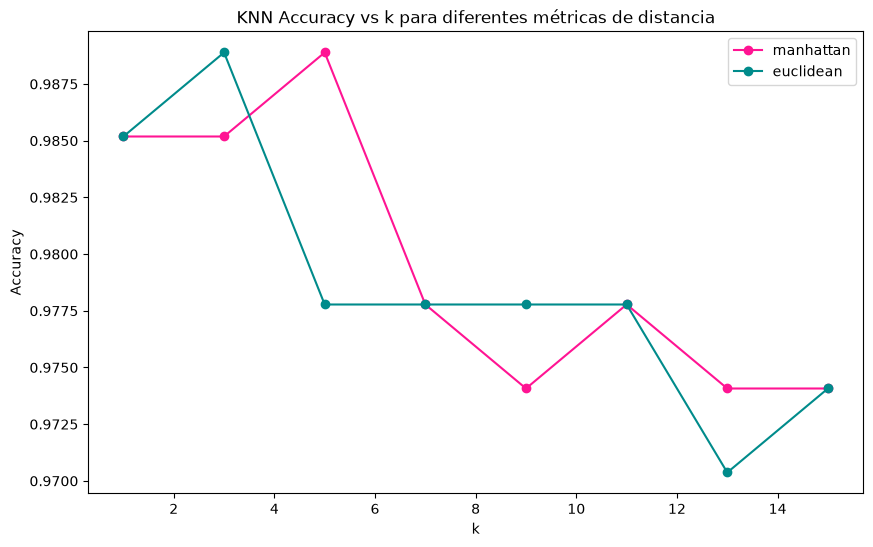

In [14]:
# Grafico de accuracy de validacion en función de k para cada métrica de distancia
plt.figure(figsize=(10, 6))

for metric in distance_metrics:
    subset = plot_data[plot_data["metric"] == metric]
    plt.plot(subset["k"], subset["accuracy"], marker='o', label=metric, color = 'deeppink' if metric == 'manhattan' else 'darkcyan')

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k para diferentes métricas de distancia")
plt.legend()
plt.show()

La combinación con mayor accuracy de validación para la métrica Manhattan es k=5, mientras que para Euclidean es k=3 ambas con un accuracy = 0.988889. 

Dado que ambas combinaciones óptimas logran el mismo accuracy, la elección debería basarse en otros criterios. Por esto se optó por **k=3 con métrica euclidean**, ya que comparar contra una menor cantidad de vecinos (k=3) implica menor costo computacional que k=5. Además, con un dataset de imágenes bien definidas como Digits (pocos vecinos ya alcanzan para identificar el dígito correctamente), un K bajo tiene sentido ya que el riesgo de sobreajuste que normalmente trae un K chico se ve compensado por lo limpio del dataset, y evita el costo computacional extra de comparar contra más vecinos.

#### Evaluación final en prueba

Una vez elegidos la métrica y $K$ usando validación:

1. unir entrenamiento y validación (`X_train_final_d, y_train_final_d`);
2. entrenar un nuevo `KNeighborsClassifier` con esos datos;
3. evaluar **una sola vez** sobre prueba (`X_test_d, y_test_d`).

In [15]:
# Mantenemos el mismo Pipeline (scaler + knn) usado en la busqueda de hiperparametros,
# para que el modelo final sea consistente con el criterio usado para elegir K y la métrica
clasificador_final = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3, metric='euclidean'))
])

X_train_final_d = np.concatenate([X_train, X_val])
y_train_final_d = np.concatenate([y_train, y_val])

clasificador_final.fit(X_train_final_d, y_train_final_d)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [16]:
# Evaluación del modelo final en el conjunto de prueba
y_test_pred = clasificador_final.predict(X_test)

accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Accuracy en el conjunto de prueba: {accuracy_test:.4f}")

Accuracy en el conjunto de prueba: 0.9630


#### Matriz de confusión de `Digits`

En un problema multiclase la matriz tiene una fila y una columna por clase.

En `Digits` tendremos diez clases:

$$
0,1,2,\ldots,9
$$

por lo que la matriz de confusión será de tamaño $10\times 10$.

- Los elementos de la **diagonal principal** corresponden a predicciones correctas.
- Un valor fuera de la diagonal indica que una clase real fue confundida con otra clase.

Esta matriz permitirá analizar qué dígitos resultan más difíciles de distinguir.

**Construimos y graficamos la matriz**

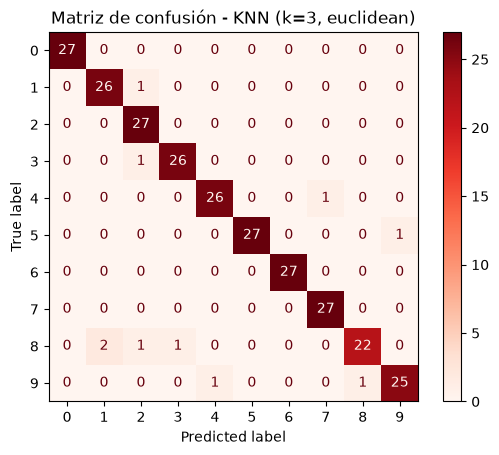

In [17]:
#matriz de confusión
matriz_confusion = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=digits.target_names)
disp.plot(cmap="Reds")
plt.title("Matriz de confusión - KNN (k=3, euclidean)")
plt.show()

**Identificamos si algún digito presenta errores**

In [18]:
# Copiamos la matriz y "apagamos" la diagonal (aciertos) para quedarnos solo con los errores
matriz_sin_diagonal = matriz_confusion.copy()
np.fill_diagonal(matriz_sin_diagonal, 0)

for real in range(matriz_confusion.shape[0]):
    errores = matriz_sin_diagonal[real].sum() #total de errores para ese digito real
    if errores > 0:
        confunsion = np.argmax(matriz_sin_diagonal[real]) #con que digito se confunde más ese dígito real
        print(f"Dígito {real}: {errores} error(es), más confundido con el dígito {confunsion}")

Dígito 1: 1 error(es), más confundido con el dígito 2
Dígito 3: 1 error(es), más confundido con el dígito 2
Dígito 4: 1 error(es), más confundido con el dígito 7
Dígito 5: 1 error(es), más confundido con el dígito 9
Dígito 8: 4 error(es), más confundido con el dígito 1
Dígito 9: 2 error(es), más confundido con el dígito 4


Se puedo observar que la matriz de confusión clasifica correctamente a la gran mayoría de los digitos con alguno errores aislados, como en los digitos 1, 3, 4 y 5 que presentan un único error. Además, se identificó que el dígito que más errores acumula es el 8, con 4 errores, confundiéndose principalmente con el 1 y le sigue el 9, con 2 errores, confundido principalmente con el 4. Entonces, concluimos que los errores aparecen dispersos entre distintos pares de dígitos.

#### ¿qué ocurre si hay un empate en la votación?

Hasta ahora utilizamos KNN suponiendo que entre los vecinos existe una clase con mayor cantidad de votos. Sin embargo, en un problema multiclase pueden producirse empates.

Analizaremos una observación particular del conjunto de prueba de `Digits`. Para ello utilizaremos temporalmente $K=4$ y $K=5$, manteniendo la distancia Euclídea.

La función `kneighbors()` permite consultar directamente cuáles son los vecinos utilizados por el clasificador y sus distancias.

Ejecute el siguiente código y analice los resultados.

`X_train_final_d, y_train_final_d` corresponden a los **conjuntos de entrenamiento y validación unidos**

`X_test_d, y_test_d` corresponde al conjunto de prueba


In [19]:
#X_train_final_d / y_train_final_d ya quedaron definidos al entrenar el modelo final
# (entrenamiento + validación unidos), por eso solo necesitamos nombrar el conjunto de prueba 
X_test_d = X_test
y_test_d = y_test

sample_index = 168
sample = X_test_d[sample_index].reshape(1, -1)

for k in [4, 5]:

    knn_tie = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean",
        weights="uniform"
    )

    knn_tie.fit(X_train_final_d, y_train_final_d)

    distances, indices = knn_tie.kneighbors(sample)
    neighbor_labels = y_train_final_d[indices[0]]
    prediction = knn_tie.predict(sample)[0]

    print(f"K = {k}")
    print("Neighbor labels:", neighbor_labels)
    print("Distances:", np.round(distances[0], 2))
    print("Prediction:", prediction)
    print()

K = 4
Neighbor labels: [9 9 9 9]
Distances: [17.06 17.83 18.06 18.17]
Prediction: 9

K = 5
Neighbor labels: [9 9 9 9 9]
Distances: [17.06 17.83 18.06 18.17 18.84]
Prediction: 9



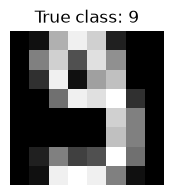

In [20]:
plt.figure(figsize=(2, 2))
plt.imshow(X_test_d[sample_index].reshape(8, 8), cmap="gray")
plt.title(f"True class: {y_test_d[sample_index]}")
plt.axis("off")
plt.show()

 #### Preguntas

1. ¿Qué ocurre con la votación cuando $K=4$?
2. ¿Qué ocurre cuando $K=5$?
3. ¿Utilizar un valor impar de $K$ garantiza que no pueda existir un empate?
4. ¿Qué clase predice `KNeighborsClassifier` en cada caso?
5. Investigue: ¿qué criterios utiliza `scikit-learn` para resolver un empate entre clases?

**1-2.** En este caso puntual (índice 168), tanto con K=4 como con K=5 no se produjo ningún empate, los 4 y los 5 vecinos más cercanos pertenecen todos a la clase 9 (con distancias entre 17.06 y 18.84), por lo que la votación fue unánime en ambos casos.

**3.** No. Un K impar solo evita el empate por cantidad de votos en un problema binario (dos clases). En un problema multiclase como Digits (10 clases), un K impar puede seguir empatando, por ejemplo, con K=5 podrían aparecer 2 vecinos de la clase A, 2 de la clase B y 1 de la clase C, y A y B quedarían empatadas igual.

**4.** En ambos casos (K=4 y K=5) predijo la clase 9.

**5.** Con `weights="uniform"` , scikit-learn resuelve los empates usando `scipy.stats.mode` internamente, que ante un empate devuelve la clase de menor valor numérico entre las empatadas. Es decir, el criterio de desempate es puramente por el valor de la etiqueta, no por cuál vecino está más cerca.

### Actividad 3 — ¿Qué métrica de evaluación conviene usar?

#### Wisconsin Diagnostic Breast Cancer

El dataset Breast Cancer Wisconsin Diagnostic contiene información obtenida a partir de imágenes digitalizadas de muestras celulares de masas mamarias. Su objetivo es distinguir entre tumores benignos y malignos.

Contiene 569 observaciones y 30 atributos numéricos. Estos atributos describen propiedades de los núcleos celulares observados en las imágenes, tales como:

radio,
textura,
perímetro,
área,
suavidad,
compacidad,
concavidad,
puntos cóncavos,
simetría,
dimensión fractal.

Para cada una de estas características se incluyen diferentes descriptores estadísticos, lo que da lugar a las 30 variables disponibles. El conjunto contiene dos clases:

- 357 casos benignos
- 212 casos malignos

En la versión original de scikit-learn, las etiquetas están codificadas como: `0 = malignant` y `1 = benign`

#### Actividad

Usar $K=5$ y distancia Euclídea.

Para facilitar la interpretación de las métricas, recodificaremos la variable objetivo como:

- `1` = maligno = **clase positiva**
- `0` = benigno = **clase negativa**

Esto es importante porque precision y recall siempre se interpretan respecto de una clase positiva.

In [21]:
cancer = load_breast_cancer(as_frame=True)

X_cancer = cancer.data

# Recodificado para que maligno sea la clase positiva
y_cancer = (cancer.target == 0).astype(int)

print("Positive class: malignant = 1")
print("Negative class: benign = 0")
print(y_cancer.value_counts().sort_index())

Positive class: malignant = 1
Negative class: benign = 0
target
0    357
1    212
Name: count, dtype: int64


#### División y escalado

Dividir en entrenamiento y prueba utilizando:

- `test_size=0.20`
- `random_state=42`
- `stratify=y_cancer`

Luego construir un pipeline:

`StandardScaler` $\rightarrow$ `KNeighborsClassifier`

con:

- `n_neighbors=5`
- `metric="euclidean"`

In [22]:
# Separamos entrenamiento (80%) y prueba (20%), manteniendo la proporción de clases
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=42, stratify=y_cancer
)

# Pipeline: escalamos los atributos y después aplicamos KNN con k=5 y distancia euclídea
pipeline_cancer = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, metric="euclidean"))
])

pipeline_cancer.fit(X_train_c, y_train_c)
y_pred_c = pipeline_cancer.predict(X_test_c)

#### Matriz de confusión

Construya la matriz de confusión.

Luego identifique:

- VP
- VN
- FP
- FN

**Responder:**

En este problema, ¿qué representa un falso negativo?

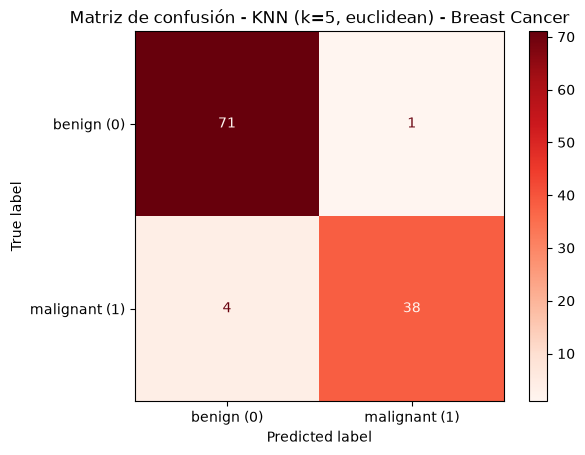

VP (malignos detectados correctamente): 38
VN (benignos detectados correctamente): 71
FP (benignos clasificados como malignos): 1
FN (malignos clasificados como benignos): 4


In [23]:
matriz_confusion_c = confusion_matrix(y_test_c, y_pred_c)

disp_c = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion_c, display_labels=["benign (0)", "malignant (1)"])
disp_c.plot(cmap="Reds")
plt.title("Matriz de confusión - KNN (k=5, euclidean) - Breast Cancer")
plt.show()

# filas=real, columnas=predicción, y clase positiva = maligno (1):
# VN está en [0,0], FP en [0,1], FN en [1,0], VP en [1,1]
VN, FP, FN, VP = matriz_confusion_c.ravel()
print(f"VP (malignos detectados correctamente): {VP}")
print(f"VN (benignos detectados correctamente): {VN}")
print(f"FP (benignos clasificados como malignos): {FP}")
print(f"FN (malignos clasificados como benignos): {FN}")

**Respuesta:**

Un falso negativo (FN) es un tumor **maligno** que el modelo clasificó como **benigno**. Es el error más grave posible en este contexto: significa que una paciente con cáncer queda sin ser detectada y no recibe el seguimiento o tratamiento que necesitaría, mientras que un falso positivo (un benigno clasificado como maligno) implica, en el peor de los casos, estudios adicionales innecesarios pero no una enfermedad no tratada.

#### Accuracy, precision, recall y F1

Calcule:

- `accuracy_score`
- `precision_score`
- `recall_score`
- `f1_score`

Recuerde que la clase positiva es `malignant = 1`.

In [24]:
accuracy_c = accuracy_score(y_test_c, y_pred_c)
precision_c = precision_score(y_test_c, y_pred_c)  #de los predichos malignos, cuantos lo eran de verdad
recall_c = recall_score(y_test_c, y_pred_c)  #de los malignos reales, cuantos detectamos
f1_c = f1_score(y_test_c, y_pred_c)    #media de precision y recall

print(f"Accuracy:  {accuracy_c:.4f}")
print(f"Precision: {precision_c:.4f}")
print(f"Recall:    {recall_c:.4f}")
print(f"F1-score:  {f1_c:.4f}")

Accuracy:  0.9561
Precision: 0.9744
Recall:    0.9048
F1-score:  0.9383


**Responder:**

1. Si el objetivo principal fuera reducir los casos malignos no detectados, ¿qué métrica debería observarse especialmente?
2. ¿Por qué un modelo con accuracy alta puede seguir siendo inadecuado para una aplicación concreta?

**Respuestas:**

1. Habría que priorizar el **recall** de la clase maligna, ya que es la métrica que mide qué proporción de los casos realmente malignos el modelo logra detectar (VP / (VP + FN)). Maximizar recall implica minimizar los falsos negativos, que es justamente lo que se busca reducir.

2. Porque el accuracy es una medida global que no distingue entre tipos de error, y se ve fuertemente afectada por el desbalance de clases. En este dataset hay más casos benignos que malignos: un modelo que casi siempre prediga "benigno" puede lograr un accuracy relativamente alto simplemente acertando la clase mayoritaria, mientras falla sistemáticamente en detectar la clase minoritaria (maligno), que es la clínicamente crítica. Por eso conviene mirar también precision, recall y F1, que sí reflejan el desempeño sobre la clase positiva.